# 03 — Topic Modelling
LDA topic modelling on post titles


In [1]:
# Shared Setup — run this first
import json, pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.dates as mdates
import seaborn as sns, warnings, re
from collections import Counter
from datetime import datetime
from tqdm import tqdm
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

POSTS_FILE    = "../data/posts_soccer.json"
COMMENTS_FILE = "../data/comments_soccer.json"

with open(POSTS_FILE, "r", encoding="utf-8") as f:
    posts_raw = json.load(f)
with open(COMMENTS_FILE, "r", encoding="utf-8") as f:
    comments_raw = json.load(f)

posts_df = pd.DataFrame([{
    "id": p.get("id"), "author": p.get("author"),
    "title": p.get("title",""), "selftext": p.get("selftext",""),
    "score": p.get("score",0), "upvote_ratio": p.get("upvote_ratio",0),
    "num_comments": p.get("num_comments",0), "subreddit": p.get("subreddit"),
    "flair": p.get("link_flair_text"), "created_utc": p.get("created_utc"),
} for p in posts_raw])

comments_df = pd.DataFrame([{
    "id": c.get("id"), "author": c.get("author"),
    "body": c.get("body",""), "score": c.get("score",0),
    "parent_id": c.get("parent_id"), "link_id": c.get("link_id"),
    "subreddit": c.get("subreddit"), "created_utc": c.get("created_utc"),
    "controversiality": c.get("controversiality",0),
} for c in comments_raw])

REMOVE = [None, "[deleted]", "AutoModerator", "BotDefense"]
posts_df["datetime"]    = pd.to_datetime(posts_df["created_utc"], unit="s")
comments_df["datetime"] = pd.to_datetime(comments_df["created_utc"], unit="s")
posts_df    = posts_df[~posts_df["author"].isin(REMOVE)].reset_index(drop=True)
comments_df = comments_df[~comments_df["author"].isin(REMOVE)].reset_index(drop=True)
posts_df["full_text"] = posts_df["title"] + " " + posts_df["selftext"].fillna("")

print(f"Posts: {len(posts_df):,} | Comments: {len(comments_df):,}")
print(f"Date range: {posts_df['datetime'].min().date()} to {posts_df['datetime'].max().date()}")


Posts: 18,088 | Comments: 45,020
Date range: 2022-10-31 to 2022-12-19


## 4. Topic Modelling (LDA)
Latent Dirichlet Allocation to discover key discussion themes.

In [2]:
import gensim
from gensim import corpora, models
from gensim.utils import simple_preprocess
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords', quiet=True)

STOP_WORDS = set(stopwords.words('english'))
# Add football-specific stopwords that don't add topic value
FOOTBALL_STOPS = {
    'football', 'soccer', 'game', 'match', 'team', 'player', 'club',
    'goal', 'season', 'league', 'cup', 'world', 'said', 'would', 'could',
    'also', 'one', 'get', 'think', 'know', 'like', 'just', 'really',
    'good', 'great', 'much', 'still', 'even', 'well', 'make', 'way'
}
STOP_WORDS.update(FOOTBALL_STOPS)

def preprocess(text):
    tokens = simple_preprocess(str(text), deacc=True, min_len=3)
    return [t for t in tokens if t not in STOP_WORDS]

# Use post titles for topic modelling (cleaner, more topical than comments)
print('Preprocessing post titles...')
docs = [preprocess(title) for title in tqdm(posts_df['title'])]
docs = [d for d in docs if len(d) >= 3]  # remove empty docs

# Build dictionary and corpus
dictionary = corpora.Dictionary(docs)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in docs]

print(f'Dictionary size: {len(dictionary):,} terms')
print(f'Corpus size:     {len(corpus):,} documents')

Preprocessing post titles...


  0%|                                                                                                                                                                | 0/18088 [00:00<?, ?it/s]

 36%|███████████████████████████████████████████████████▉                                                                                              | 6432/18088 [00:00<00:00, 63785.36it/s]

 71%|██████████████████████████████████████████████████████████████████████████████████████████████████████▋                                          | 12811/18088 [00:00<00:00, 63626.98it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18088/18088 [00:00<00:00, 64107.03it/s]

Dictionary size: 4,201 terms
Corpus size:     16,061 documents


In [3]:
# ── TRAIN LDA MODEL ────────────────────────────────────────────────────────
NUM_TOPICS = 8

print(f'Training LDA model with {NUM_TOPICS} topics...')
lda_model = models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

print('\n=== DISCOVERED TOPICS ===')
topic_labels = {
    0: 'Match Results',
    1: 'Transfers',
    2: 'Player Performance',
    3: 'Tactical Discussion',
    4: 'Manager News',
    5: 'Fan Reactions',
    6: 'Statistics & Records',
    7: 'Media & Controversy'
}

for i in range(NUM_TOPICS):
    words = lda_model.show_topic(i, topn=8)
    word_str = ', '.join([w for w, _ in words])
    print(f'  Topic {i} [{topic_labels.get(i, "")}]: {word_str}')

Training LDA model with 8 topics...



=== DISCOVERED TOPICS ===
  Topic 0 [Match Results]: final, time, first, england, instagram, mbappe, goals, ever
  Topic 1 [Transfers]: qatar, brazil, fans, stadium, video, neymar, switzerland, card
  Topic 2 [Player Performance]: ronaldo, cristiano, man, year, official, manager, today, fifa
  Topic 3 [Tactical Discussion]: croatia, group, argentine, south, perfect, uefa, stage, korea
  Topic 4 [Manager News]: argentina, messi, france, fifa, win, post, winning, lionel
  Topic 5 [Fan Reactions]: morocco, sign, dominik, agreement, times, crazy, fun, shirts
  Topic 6 [Statistics & Records]: players, portugal, spain, miss, argentinians, play, last, people
  Topic 7 [Media & Controversy]: united, scored, real, three, madrid, news, manchester, celebrations


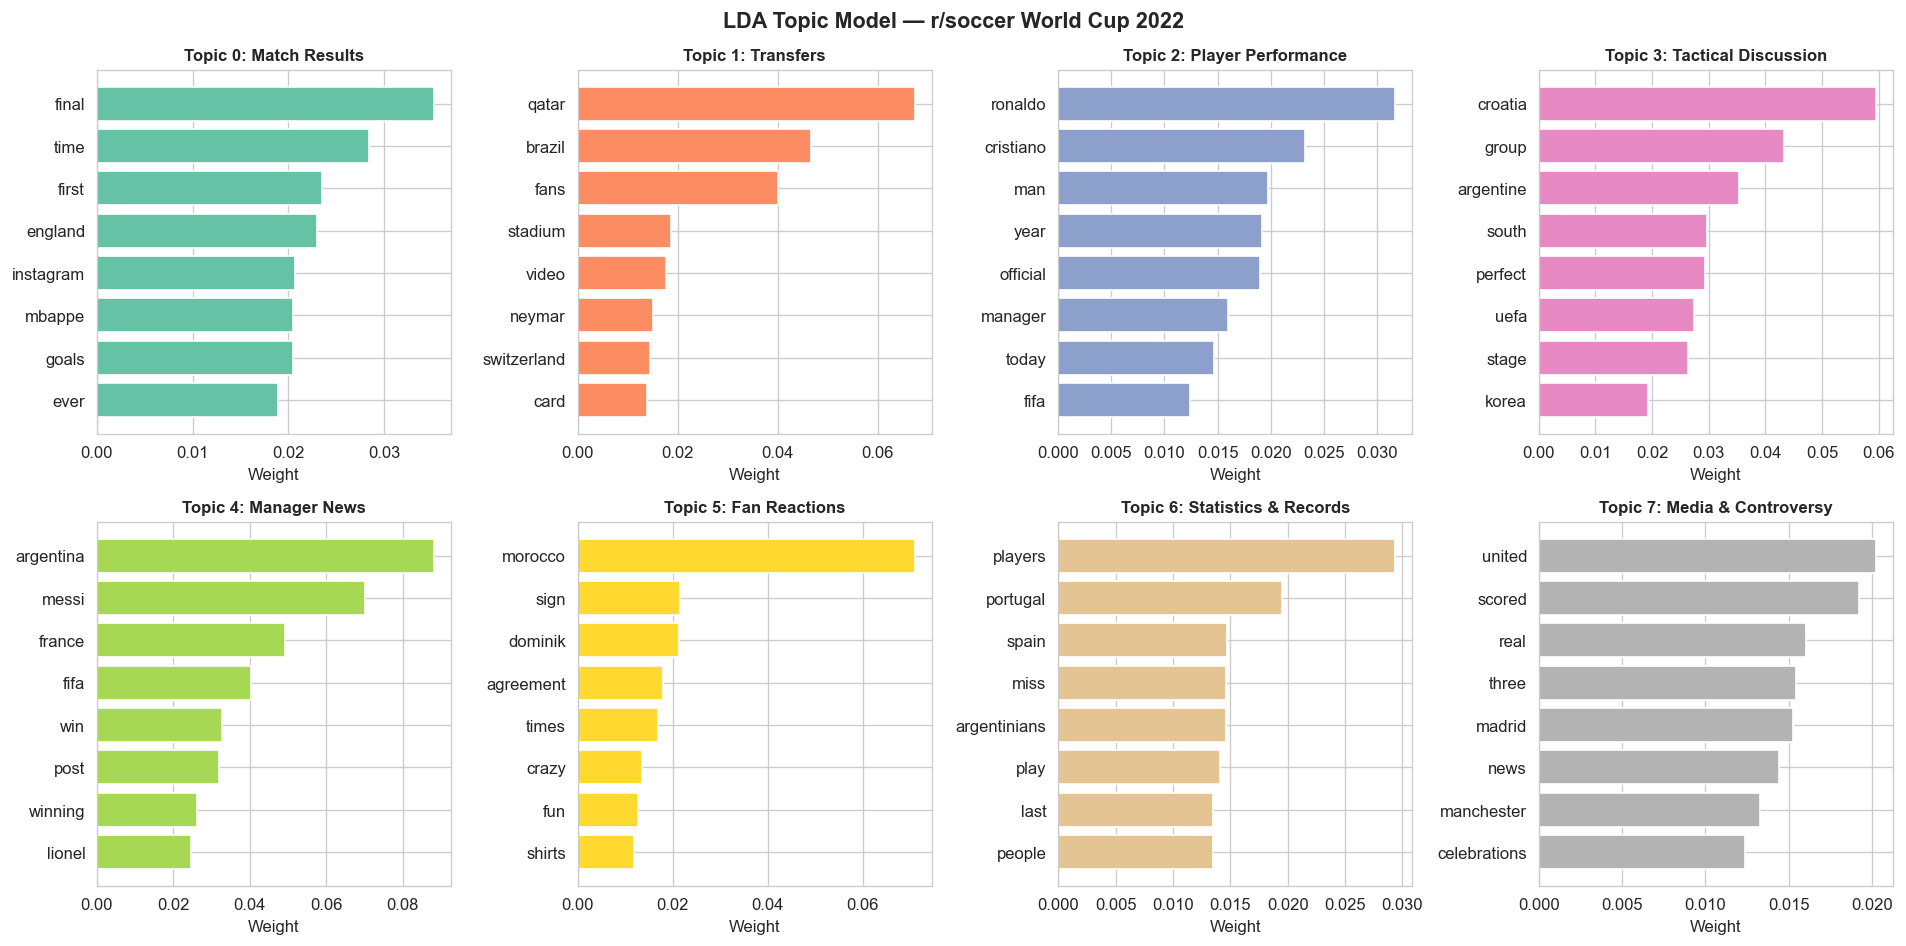

Saved: topic_modelling.png


In [4]:
# ── TOPIC VISUALISATION ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
colors_topics = plt.cm.Set2(np.linspace(0, 1, NUM_TOPICS))

for i in range(NUM_TOPICS):
    words = lda_model.show_topic(i, topn=8)
    terms  = [w for w, _ in words]
    scores = [s for _, s in words]
    axes[i].barh(terms[::-1], scores[::-1], color=colors_topics[i])
    axes[i].set_title(f'Topic {i}: {topic_labels.get(i, "")}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Weight')

plt.suptitle('LDA Topic Model — r/soccer World Cup 2022', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('topic_modelling.png', bbox_inches='tight')
plt.show()
print('Saved: topic_modelling.png')

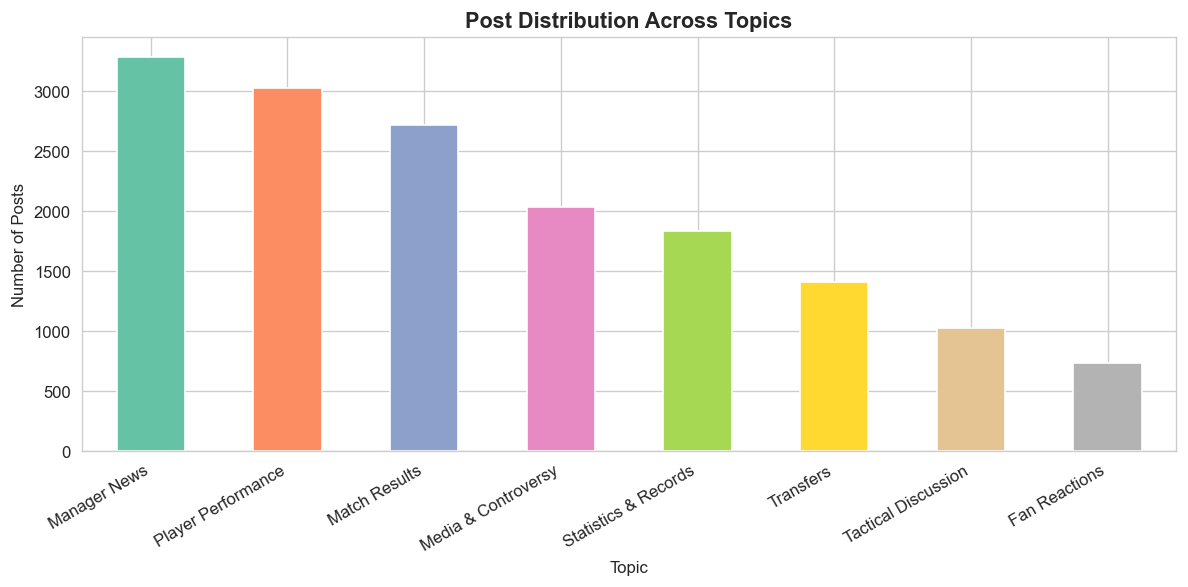

In [5]:
# ── ASSIGN DOMINANT TOPIC TO EACH POST ────────────────────────────────────
def get_dominant_topic(bow):
    topics = lda_model.get_document_topics(bow)
    if not topics:
        return -1
    return max(topics, key=lambda x: x[1])[0]


dominant_topics = [get_dominant_topic(c) for c in corpus]

posts_df = posts_df.iloc[:len(dominant_topics)].copy()

posts_df['dominant_topic'] = dominant_topics
posts_df['topic_label'] = posts_df['dominant_topic'].map(topic_labels)
posts_df['topic_label']    = posts_df['dominant_topic'].map(topic_labels)

topic_dist = posts_df['topic_label'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
topic_dist.plot(kind='bar', ax=ax, color=colors_topics[:len(topic_dist)], edgecolor='white')
ax.set_title('Post Distribution Across Topics', fontsize=13, fontweight='bold')
ax.set_xlabel('Topic')
ax.set_ylabel('Number of Posts')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('topic_distribution.png', bbox_inches='tight')
plt.show()

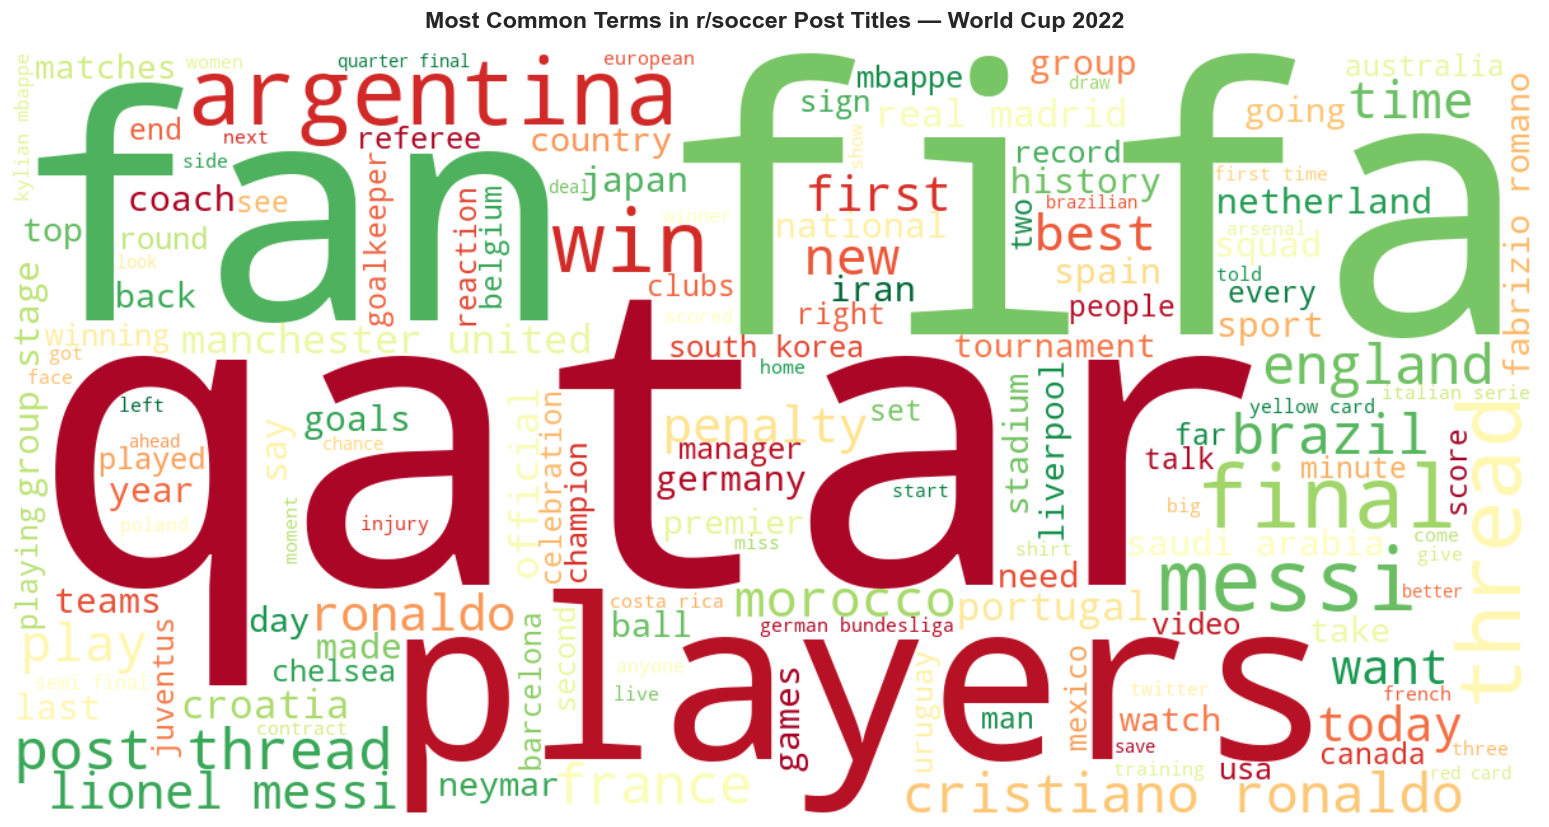

Saved: wordcloud.png


In [6]:
# ── WORDCLOUD ──────────────────────────────────────────────────────────────
from wordcloud import WordCloud

all_words = ' '.join([' '.join(doc) for doc in docs])
wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='RdYlGn',
    max_words=150
).generate(all_words)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Terms in r/soccer Post Titles — World Cup 2022',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('wordcloud.png', bbox_inches='tight')
plt.show()
print('Saved: wordcloud.png')